<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/Transfer_Learning_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here we will conduct a series of experiments with different models trained for our main Food Vision Classifier model.

1. `model_1` - use featue extraction transfer learning with 1 % of the training data with data augmentation.
2. `model_2` - use feature extraction transfer learning with 10 % of the training with data augmentation.
3. `model_3` - use fine-tuning transfer learning on 10 % of the training data with data augmentation.
4. `model_4` - use fine-tuning transfer learning on 100 % of the training data with data augmentation.

> **Note:** throughtout all experiments the same tets dataset will be uesd to evaluate our model...this ensures consistency across evaluation matrices.

## Getting and preprocessing data for model_1

In [3]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-05-22 05:38:57--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-22 05:38:57 (121 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [4]:
from helper_functions import unzip_data

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

unzip_data("10_food_classes_1_percent.zip")

--2026-05-22 05:39:02--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   108MB/s    in 1.2s    

2026-05-22 05:39:03 (108 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [5]:
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"

In [6]:
from helper_functions import walk_through_dir
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There a

In [7]:
import tensorflow as tf
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_1_percent,
                                                                      image_size=IMG_SIZE,
                                                                      label_mode="categorical",
                                                                      batch_size=BATCH_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size = IMG_SIZE,
                                                                batch_size = BATCH_SIZE)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


## Adding data augmentation into our model

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    # layers.Rescale(1./255)
], name = "data_augmentation")

## Visualize our data augmentation layer

10_food_classes_1_percent/train/steak


Text(0.5, 1.0, 'Augmented random image from class: steak')

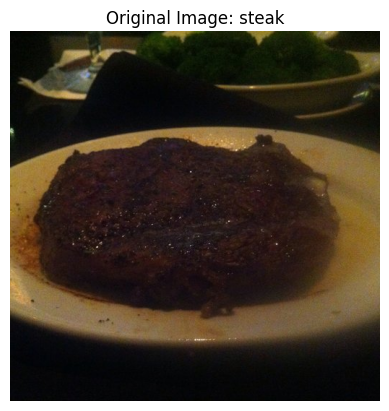

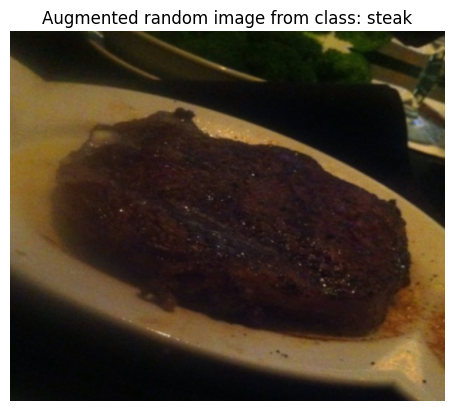

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/" + target_class
random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + "/" + random_image
print(target_dir)
img = mpimg.imread(random_image_path)
plt.title(f"Original Image: {target_class}")
plt.axis(False);
plt.imshow(img)
# Plotting our augmented image
augmented_image = data_augmentation(tf.expand_dims(img, axis=0))
plt.figure()
plt.axis(False);
plt.imshow(tf.squeeze(augmented_image)/255.)
plt.title(f"Augmented random image from class: {target_class}")

Our baseline model was trained on 10 % of our dataset

# Model 1 : Feature extraction transfer learning on 1 % of the data with data augmentation

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from helper_functions import create_tensorboard_callback
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
], name = "data_augmentation")

input_shape = (224,224,3)
base_model = tf.keras.applications.EfficientNetV2B0(include_top=False)
base_model.trainable = False
inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(10, activation="softmax", name = "output_layer")(x)
model_1 = keras.Model(inputs, outputs, name = "model_1")
model_1.compile(loss="categorical_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
history_1_percent = model_1.fit(train_data_1_percent,
                               epochs=5,
                               steps_per_epoch = len(train_data_1_percent),
                               validation_data = test_data,
                               validation_steps = int(len(test_data)),
                               callbacks = [create_tensorboard_callback(dir_name="transfer_learning",
                                                                       experiment_name = "1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260522-053914
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 0.1143 - loss: 2.3712 - val_accuracy: 0.1724 - val_loss: 2.2097
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.2429 - loss: 2.1230 - val_accuracy: 0.2616 - val_loss: 2.1042
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.3857 - loss: 1.9852 - val_accuracy: 0.3384 - val_loss: 2.0143
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 0.4286 - loss: 1.8400 - val_accuracy: 0.3952 - val_loss: 1.9291
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.5857 - loss: 1.7214 - val_accuracy: 0.4348 - val_loss: 1.8493


In [12]:
IMG_SIZE + (3,)

(224, 224, 3)

In [13]:
# Checking our model_1 summary
model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

In [14]:
results_1_percent = model_1.evaluate(test_data)
results_1_percent[1]

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.4348 - loss: 1.8493


0.43479999899864197

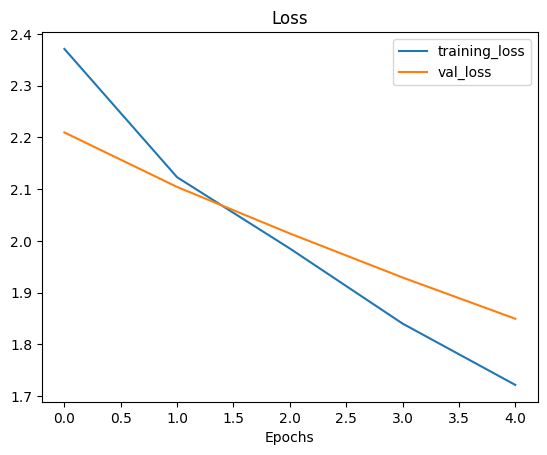

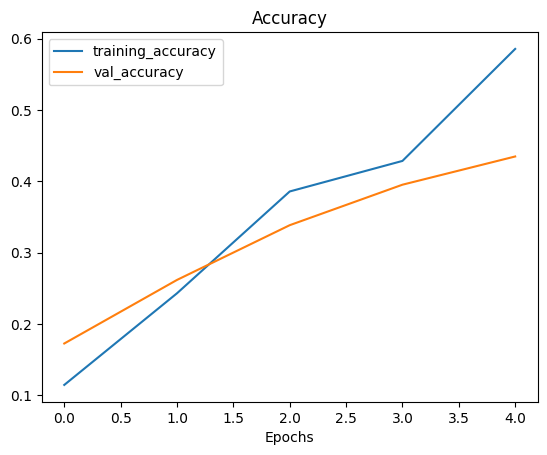

In [15]:
from helper_functions import plot_loss_curves
plot_loss_curves(history_1_percent)

# Model 2 : traing our model on 10 % of dataset

In [16]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
unzip_data("10_food_classes_10_percent.zip")

--2026-05-22 05:40:24--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   182MB/s    in 0.9s    

2026-05-22 05:40:25 (182 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [17]:
train_dir_10_percent = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

In [18]:
import tensorflow as tf
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_10_percent,
                                                                      image_size=IMG_SIZE,
                                                                      label_mode="categorical",
                                                                      batch_size=BATCH_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size = IMG_SIZE,
                                                                batch_size = BATCH_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [19]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2)], name="data_augmentation")

In [20]:
input_shape = (224,224,3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_2D")(x)
outputs = layers.Dense(10, activation="softmax", name = "output_layer")(x)
model_2 = keras.Model(inputs, outputs, name="output_layer")
model_2.compile(loss="categorical_crossentropy",
                optimizer = "Adam",
                metrics=["accuracy"])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model_2.summary()

Model: "output_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_2D       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Creating a model checkpoint callback

In [22]:
checkpoint_path = "ten_percent_model_checkpoints__weights/checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only = True,
                                                         save_best_only=False,
                                                         save_freq= "epoch",
                                                         verbose=1)

## Fit model 2 passing in the ModelCheckpoint callback

In [23]:
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                 epochs=initial_epochs,
                                 steps_per_epoch = len(train_data_10_percent),
                                 validation_data = test_data,
                                 validation_steps = int(0.25*len(test_data)),
                                 callbacks = [create_tensorboard_callback(dir_name="transfer_learning", experiment_name="10_percent_data_aug"),
                                              checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260522-054028
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.1985 - loss: 2.2739
Epoch 1: saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5

Epoch 1: finished saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 424ms/step - accuracy: 0.3040 - loss: 2.0582 - val_accuracy: 0.6859 - val_loss: 1.4771
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6644 - loss: 1.4557
Epoch 2: saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5

Epoch 2: finished saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.6853 - loss: 1.3568 - val_accuracy: 0.7928 - val_loss: 1.0313
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7539 - loss: 1.1118
Epoch 3: saving model to ten_percent_model_checkpoints__wei

In [24]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.4348 - loss: 1.8493


[1.8493373394012451, 0.43479999899864197]

In [25]:
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.8336 - loss: 0.6464


[0.6463896632194519, 0.8335999846458435]

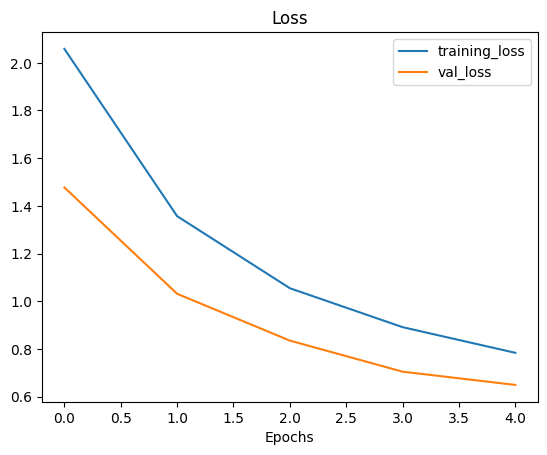

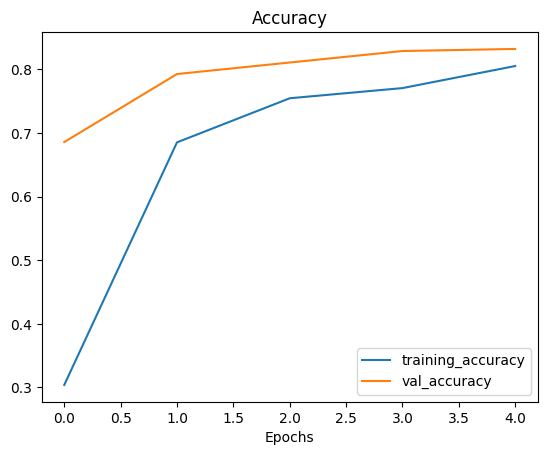

In [26]:
plot_loss_curves(history_10_percent_data_aug)

In [27]:
model_2.load_weights(checkpoint_path)

In [28]:
# Evaluate our model_2 with loaded weights
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.8336 - loss: 0.6464


In [29]:
results_10_percent_data_aug

[0.6463896632194519, 0.8335999846458435]

In [30]:
loaded_weights_model_results

[0.6463895440101624, 0.8335999846458435]

In [31]:
import numpy as np
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))

array([ True,  True])

# Model 3 : fin-tuning an existing model for 10% of data

In [32]:
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=data_augmentation, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling_2D, built=True>,
 <Dense name=output_layer, built=True>]

In [33]:
for layer in model_2.layers:
  print(layers, layer.trainable)

<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> False
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True


In [34]:
for i, layer in enumerate(model_2.layers[2].layers):
  print(i, layer.name, layer.trainable)

0 input_layer_3 False
1 rescaling_1 False
2 normalization_1 False
3 rescaling_2 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [35]:
print(len(model_2.layers[2].trainable_variables))

0


In [36]:
# We will set the last ten layers of our base model.trainable = True
base_model.trainable = True

for layer in base_model.layers[:-10]:
  layer.trainable = False

# Recompiling every time we make a change
model_2.compile(loss="categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
                metrics=["accuracy"])

In [37]:
print(len(model_2.trainable_variables))

12


### Fine tuning for another 5 epochs

In [38]:
fine_tune_epochs = initial_epochs + 5

history_fine_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                               epochs = fine_tune_epochs,
                                               validation_data = test_data,
                                               validation_steps = int(0.25 * len(test_data)),
                                                                      initial_epoch = history_10_percent_data_aug.epoch[-1],
                                                                      callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                                                            experiment_name = "10_percent_fine_tune_last_10_steps")])

Saving TensorBoard log files to: transfer_learning/10_percent_fine_tune_last_10_steps/20260522-054140
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - accuracy: 0.7853 - loss: 0.8236 - val_accuracy: 0.8322 - val_loss: 0.5930
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.8280 - loss: 0.6849 - val_accuracy: 0.8438 - val_loss: 0.5418
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.8520 - loss: 0.6057 - val_accuracy: 0.8339 - val_loss: 0.5283
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.8507 - loss: 0.5720 - val_accuracy: 0.8586 - val_loss: 0.4731
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.8827 - loss: 0.5005 - val_accuracy: 0.8553 - val_loss: 0.4711
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.8787 - loss: 0.4870 - val_accuracy: 0.8536 - val_loss: 0.4773


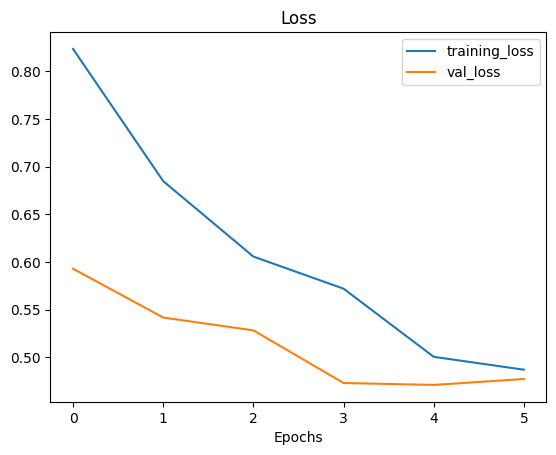

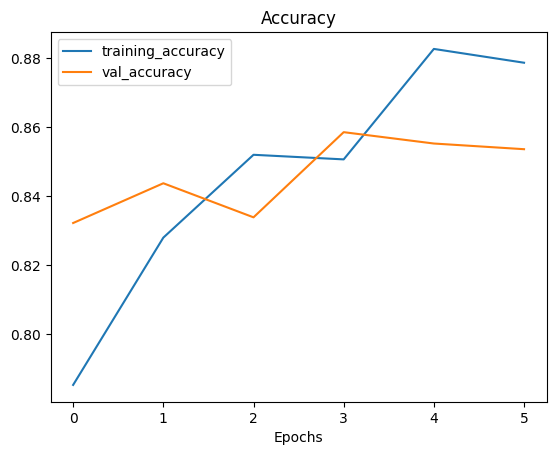

In [39]:
plot_loss_curves(history_fine_10_percent_data_aug)

In [40]:
resutls_fine_tune_10_percent = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8592 - loss: 0.4380


## Comparing all of our models

In [41]:
def compare_histories(original_history, new_history, initial_epochs=5):
  """
  Compares two tf history obj.
  """
  acc = original_history.history["accuracy"]
  loss = original_history.history["loss"]

  val_acc = original_history.history["val_accuracy"]
  val_loss = original_history.history["val_loss"]

  total_acc = acc + new_history.history["accuracy"]
  total_loss = loss + new_history.history["loss"]

  total_val_acc = val_acc + new_history.history["val_accuracy"]
  total_val_loss = val_loss + new_history.history["val_loss"]

  plt.figure(figsize = (8,8))
  plt.subplot(2,1,1)
  plt.plot(total_acc, label="Training Accuracy")
  plt.plot(total_val_acc, label="Validation Accuracy")
  plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label="Start Fine Tuning")
  plt.legend(loc="lower right")
  plt.title("Training and Validation Accuracy")

  plt.subplot(2,1,2)
  plt.plot(total_loss, label="Training Loss")
  plt.plot(total_val_loss, label="Validation Loss")
  plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label="Start Fine Tuning")
  plt.legend(loc="upper right")
  plt.title("Training and Validation Loss")
  plt.xlabel("Epoch")
  plt.show()

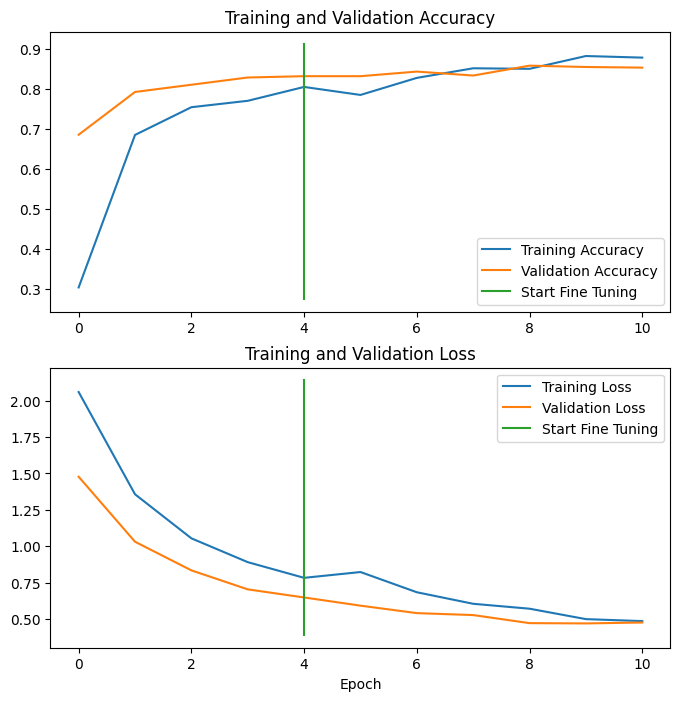

In [42]:
compare_histories(history_10_percent_data_aug, history_fine_10_percent_data_aug,
                  initial_epochs=5)

# Model 4

In [43]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
unzip_data("10_food_classes_all_data.zip")

--2026-05-22 05:42:47--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip.2’

10_food_classes_all 100%[===================>] 495.13M   283MB/s    in 1.7s    

2026-05-22 05:42:49 (283 MB/s) - ‘10_food_classes_all_data.zip.2’ saved [519183241/519183241]



In [45]:
train_dir_all_data = "10_food_classes_all_data/train"
test_dir= "10_food_classes_all_data/test"

walk_through_dir("10_food_classes_all_data")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.

In [46]:
import tensorflow as tf
IMG_SIZE = (224,224)
train_data_10_classes_full = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_all_data,
                                                                      image_size=IMG_SIZE,
                                                                      label_mode="categorical",
                                                                      batch_size=BATCH_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode= "categorical",
                                                                image_size= IMG_SIZE)


Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


The test dataset we've loaded in is the same as what we've been using for previous experiments

In [47]:
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8592 - loss: 0.4380


[0.4380445182323456, 0.8592000007629395]

In [48]:
resutls_fine_tune_10_percent

[0.4380444884300232, 0.8592000007629395]

The diff. btwn. model_3 and model_4 is the amount of data we are using to train them

In [50]:
model_2.load_weights(checkpoint_path);

In [51]:
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8336 - loss: 0.6464


[0.6463896036148071, 0.8335999846458435]

In [52]:
results_10_percent_data_aug

[0.6463896632194519, 0.8335999846458435]

The accuracy of model_2 dropped from 85.9 % to 83.3 % after we loaded the previous weights of model_2

In [53]:
# Checking which layers are trainable
for layer_number, layer in enumerate(model_2.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer True
1 data_augmentation True
2 efficientnetb0 True
3 global_average_pooling_2D True
4 output_layer True


In [54]:
for layer_number, layer in enumerate(model_2.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_3 False
1 rescaling_1 False
2 normalization_1 False
3 rescaling_2 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [57]:
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                metrics=["accuracy"])

In [58]:
fine_tune_epochs = initial_epochs + 5

history_fine_10_classes_full = model_2.fit(train_data_10_classes_full,
                                           epochs = fine_tune_epochs,
                                           validation_data = test_data,
                                           validation_steps = int(0.25 * len(test_data)),
                                           initial_epoch = history_10_percent_data_aug.epoch[-1],
                                           callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                                  experiment_name="full_10_classes_fine_tune_last_ten")])


Saving TensorBoard log files to: transfer_learning/full_10_classes_fine_tune_last_ten/20260522-061022
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 150ms/step - accuracy: 0.7692 - loss: 0.7745 - val_accuracy: 0.8832 - val_loss: 0.3656
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 142ms/step - accuracy: 0.8195 - loss: 0.5926 - val_accuracy: 0.9095 - val_loss: 0.2934
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 143ms/step - accuracy: 0.8343 - loss: 0.5274 - val_accuracy: 0.9013 - val_loss: 0.2819
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.8485 - loss: 0.4755 - val_accuracy: 0.9145 - val_loss: 0.2490
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 146ms/step - accuracy: 0.8589 - loss: 0.4482 - val_accuracy: 0.9079 - val_loss: 0.2507
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.8693 - loss: 0.4165 - val_accuracy: 0.9128 - val_loss: 0.2593


In [59]:
!nvidia-smi

Fri May 22 06:14:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             43W /   70W |    2169MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [60]:
results_fine_tune_full_data = model_2.evaluate(test_data)
results_fine_tune_full_data

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9140 - loss: 0.2657


[0.2657015025615692, 0.9139999747276306]

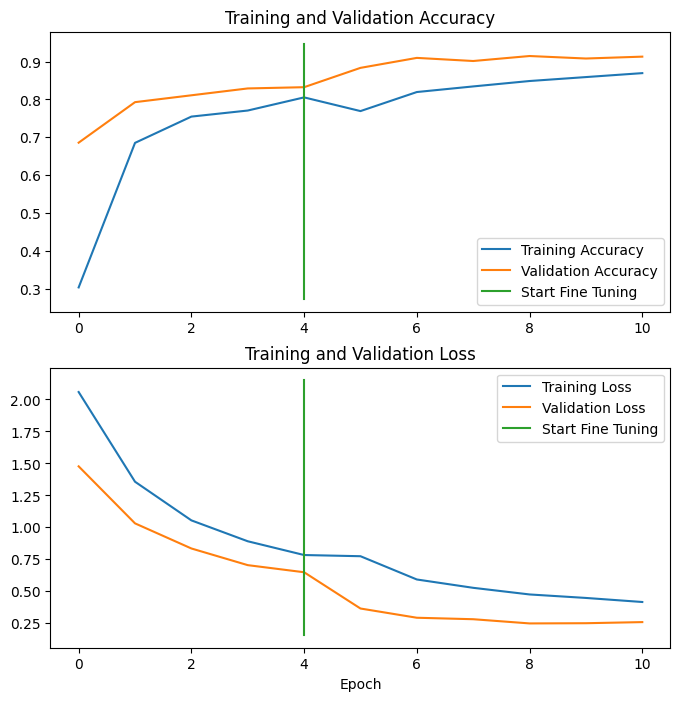

In [63]:
compare_histories(history_10_percent_data_aug, history_fine_10_classes_full, initial_epochs=5)